In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error
import joblib

In [2]:
df = pd.read_csv("menstrual_data.csv")
pd.set_option('display.max_columns', None)

In [3]:
df.head()

,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,TotalNumberofHighDays,TotalHighPostPeak,TotalNumberofPeakDays,TotalDaysofFertility,TotalFertilityFormula,LengthofMenses,MeanMensesLength,MensesScoreDayOne,MensesScoreDayTwo,MensesScoreDayThree,MensesScoreDayFour,MensesScoreDayFive,MensesScoreDaySix,MensesScoreDaySeven,MensesScoreDayEight,MensesScoreDayNine,MensesScoreDayTen,MensesScoreDay11,MensesScoreDay12,MensesScoreDay13,MensesScoreDay14,MensesScoreDay15,TotalMensesScore,MeanBleedingIntensity,NumberofDaysofIntercourse,IntercourseInFertileWindow,UnusualBleeding,PhasesBleeding,IntercourseDuringUnusBleed,Age,AgeM,Maristatus,MaristatusM,Yearsmarried,Wedding,Religion,ReligionM,Ethnicity,EthnicityM,Schoolyears,SchoolyearsM,OccupationM,IncomeM,Height,Weight,Reprocate,Numberpreg,Livingkids,Miscarriages,Abortions,Medvits,Medvitexplain,Gynosurgeries,LivingkidsM,Boys,Girls,MedvitsM,MedvitexplainM,Urosurgeries,Breastfeeding,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1,0,1,0,29,27.33,17,12,12,5,0,2,9,15,5,4.49,3,3,2,1,1,,,,,,,,,,,10,9.04,5,1,0,,,36,39,0,0,10,,0,0,0,0,8,8,3,5,63,120,0,3,3,0,0,0,,,,,,0,,,0,9,,,2,7,7,1,1,0,21.254724111867
1,nfp8122,2,0,1,0,27,,15,12,13,2,0,2,6,13,5,,3,3,2,1,1,,,,,,,,,,,10,,6,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,nfp8122,3,0,1,0,29,,15,14,,1,0,2,5,13,5,,3,3,2,1,1,,,,,,,,,,,10,,5,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,nfp8122,4,0,1,0,27,,15,12,13,2,0,2,6,13,5,,3,3,3,2,1,,,,,,,,,,,12,,3,0,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4,nfp8122,5,0,1,0,28,,16,12,12,4,0,2,8,14,5,,3,3,2,2,1,,,,,,,,,,,11,,5,1,0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [4]:
df.shape

(1665, 80)

In [5]:
df.columns

Index(['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot',
       'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength',
       'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh',
       'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays',
       'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses',
       'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo',
       'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive',
       'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight',
       'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11',
       'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14',
       'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity',
       'NumberofDaysofIntercourse', 'IntercourseInFertileWindow',
       'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed',
       'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1665 entries, 0 to 1664
Data columns (total 80 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ClientID                    1665 non-null   object
 1   CycleNumber                 1665 non-null   int64 
 2   Group                       1665 non-null   int64 
 3   CycleWithPeakorNot          1665 non-null   int64 
 4   ReproductiveCategory        1665 non-null   int64 
 5   LengthofCycle               1665 non-null   int64 
 6   MeanCycleLength             1665 non-null   object
 7   EstimatedDayofOvulation     1665 non-null   object
 8   LengthofLutealPhase         1665 non-null   object
 9   FirstDayofHigh              1665 non-null   object
 10  TotalNumberofHighDays       1665 non-null   object
 11  TotalHighPostPeak           1665 non-null   object
 12  TotalNumberofPeakDays       1665 non-null   object
 13  TotalDaysofFertility        1665 non-null   obje

In [7]:
df.describe()

,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle
count,1665.000000,1665.000000,1665.000000,1665.000000,1665.000000
mean,8.040841,0.382583,0.912312,0.055255,29.299099
std,6.593686,0.486164,0.282925,0.479706,3.887932
min,1.000000,0.000000,0.000000,0.000000,18.000000
25%,3.000000,0.000000,1.000000,0.000000,27.000000
50%,7.000000,0.000000,1.000000,0.000000,29.000000
75%,11.000000,1.000000,1.000000,0.000000,31.000000
max,45.000000,1.000000,1.000000,9.000000,54.000000


In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing Values:\n", missing)


Missing Values:
 Series([], dtype: int64)


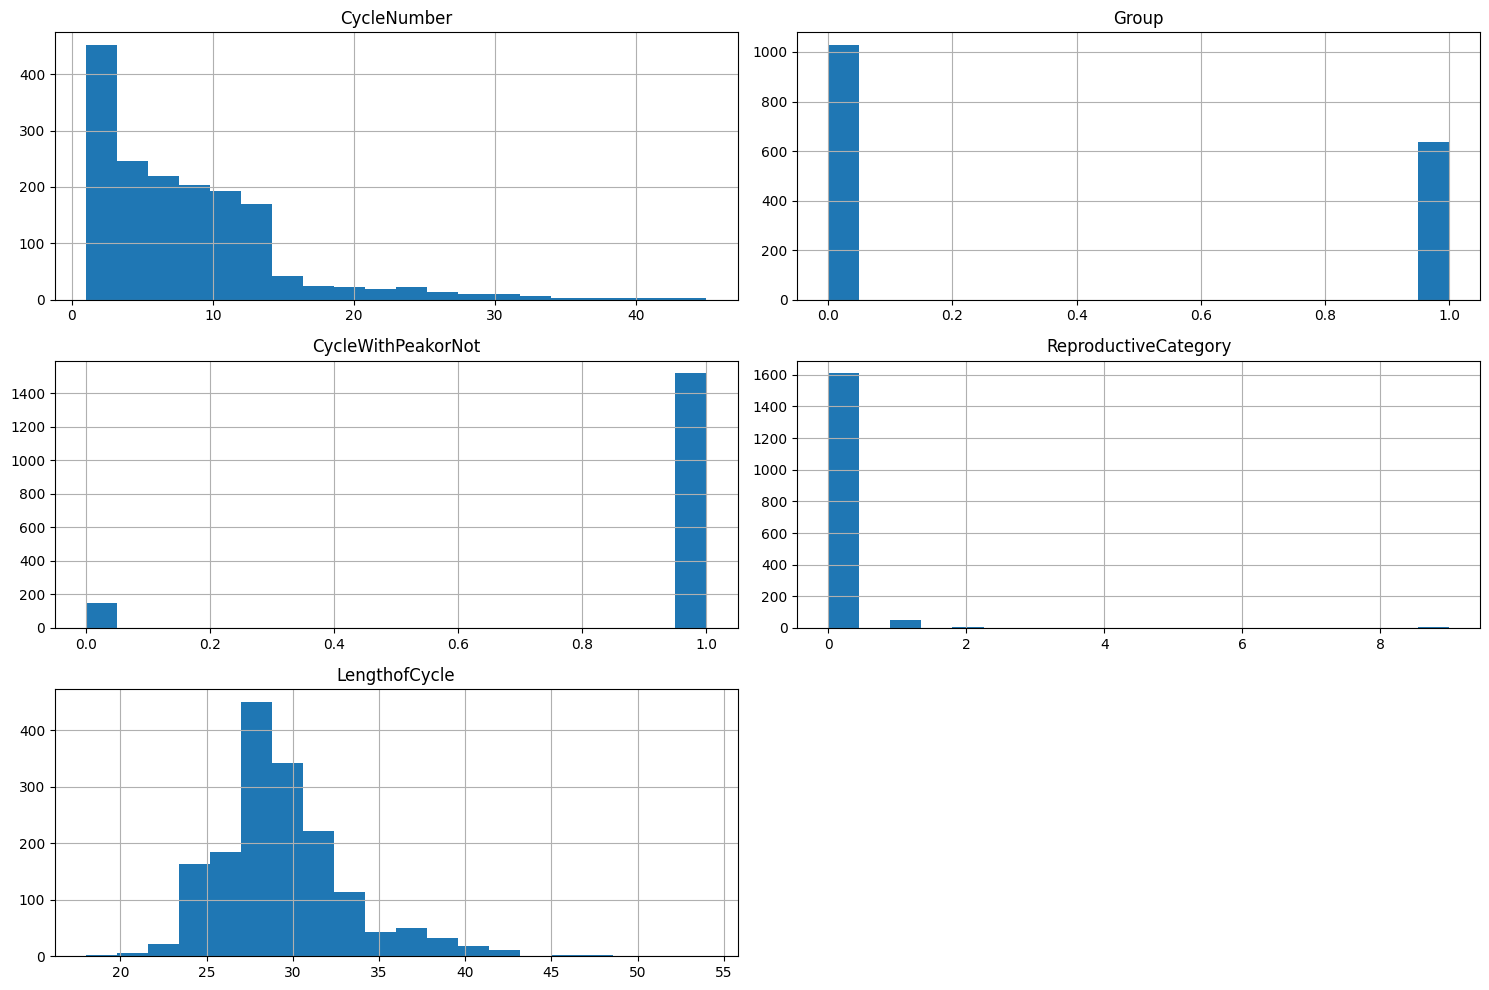

In [9]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

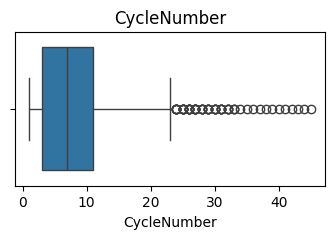

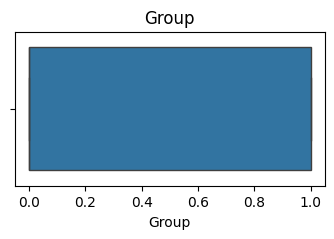

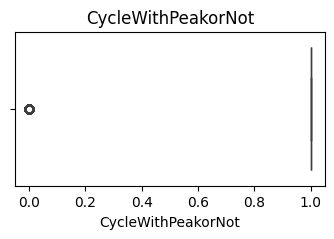

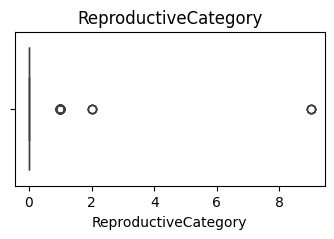

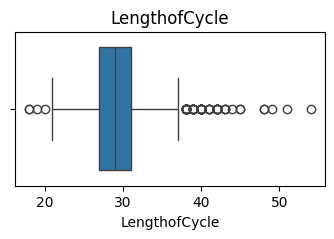

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.select_dtypes(include=['int64','float64']).columns[:10]:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
skewness = df.select_dtypes(include=['int64','float64']).skew()
print(skewness.sort_values(ascending=False))

ReproductiveCategory    15.982426
CycleNumber              1.851259
LengthofCycle            1.289486
Group                    0.483618
CycleWithPeakorNot      -2.918144
dtype: float64


In [12]:
df['LengthofCycle'] = pd.to_numeric(df['LengthofCycle'], errors='coerce')
df['LengthofCycle'].fillna(df['LengthofCycle'].median(), inplace=True)

C:\Users\Arya\AppData\Local\Temp\ipykernel_9488\4245267124.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LengthofCycle'].fillna(df['LengthofCycle'].median(), inplace=True)


In [13]:
df['baseline'] = df.groupby('ClientID')['LengthofCycle'] \
                   .transform(lambda x: x.rolling(3, min_periods=1).mean())
df['baseline'] = df['baseline'].replace('', np.nan) #convert empty strings to NaN


In [14]:
df['baseline'] = df['LengthofCycle'].rolling(window=3, min_periods=1).mean()
df['target_adjustment'] = df['LengthofCycle'] - df['baseline']

In [15]:
drop_cols = [
    'ClientID',
    'CycleNumber',

    # duplicate encoded
    'AgeM','MaristatusM','ReligionM','EthnicityM',
    'SchoolyearsM','MedvitsM','MedvitexplainM',
    'LivingkidsM','SpousesameM','NextpregM',

    # text / noisy
    'Medvitexplain','Whychart','Methoddate',

]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [16]:
leak_cols = [
    'MeanCycleLength',   # safe to drop NOW
    'EstimatedDayofOvulation',
    'LengthofLutealPhase',
    'TotalDaysofFertility',
    'TotalFertilityFormula'
]

df.drop(columns=leak_cols, inplace=True, errors='ignore')

In [17]:
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [18]:
X = df.drop(columns=['LengthofCycle', 'target_adjustment'], errors='ignore')
y = df['target_adjustment']

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,          
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,150
,criterion,'squared_error'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred_adjustment = model.predict(X_test)
baseline_test = df.loc[X_test.index, 'baseline']
final_prediction = baseline_test + y_pred_adjustment

In [26]:
actual = df.loc[X_test.index, 'LengthofCycle']

mae = mean_absolute_error(actual, final_prediction)

print("Hybrid Model MAE:", mae)

Hybrid Model MAE: 1.6811639089198305


In [27]:
from sklearn.metrics import mean_absolute_error

# TRAIN predictions
train_pred_adjustment = model.predict(X_train)
train_baseline = df.loc[X_train.index, 'baseline']
train_final = train_baseline + train_pred_adjustment

train_actual = df.loc[X_train.index, 'LengthofCycle']

train_mae = mean_absolute_error(train_actual, train_final)


# TEST predictions (you already have)
test_mae = mae

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)


Train MAE: 1.3765312889707735
Test MAE: 1.6811639089198305


In [29]:
confidence = 1 - (abs(final_prediction  - baseline_test) / 10)
print("Prediction Confidence (0-1):", confidence)

Prediction Confidence (0-1): 940     0.987416
986     0.984620
405     0.982956
721     0.974627
1610    0.979545
          ...   
231     0.984979
643     0.975823
1418    0.979533
715     0.895436
163     0.982196
Name: baseline, Length: 333, dtype: float64


In [30]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

scores = cross_val_score(model, X, y, cv=kf, scoring=mae_scorer)

print("MAE scores:", -scores)
print("Mean MAE:", -scores.mean())

MAE scores: [1.67127995 1.59726535 1.62218708 1.57497686 1.78019055]
Mean MAE: 1.6491799563702099


In [43]:
import joblib
# Save model
joblib.dump(model, 'menstrual_model.joblib')


['menstrual_model.joblib']